# Intan .rhd Deep-Dive Notebook (Channel-First Workflow)

This notebook is intentionally **.rhd-centric** and organized in the exact order requested.

## Workflow (strict order)
1. Build a reproducible file index for `.rhd` and `.mat` recordings.
2. Explore **channel metadata and channel-level signal behavior** across many `.rhd` files.
3. Print the **most outstanding channels** with explicit ranking metrics.
4. Print a **full channel report for one specific `.rhd` file**.
5. Concatenate `DORSI_PLANTAR_PART1 + PART2` and plot alongside `.mat` target angle with clear dorsiflexion vs plantarflexion regions.

## What “outstanding channels” means here
A channel is flagged as outstanding when it strongly stands out in one or more of:

- `std_uV`: high temporal variability.
- `peak_abs_uV`: large excursions.
- `rms_uV`: sustained signal energy.
- `electrode_impedance_magnitude`: unusual electrode coupling behavior.

All rankings are printed to keep selection auditable.

In [1]:
from collections import defaultdict
from pathlib import Path
import re
import sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# Resolve project root and import parser utility
project_root_candidates = [Path.cwd(), Path.cwd().parent]
project_root = next((p for p in project_root_candidates if (p / "python_files" / "utils.py").exists() or (p / "utils.py").exists()), None)
if project_root is None:
    raise FileNotFoundError("Could not infer project root containing utils.py")

if (project_root / "python_files").exists():
    sys.path.insert(0, str(project_root / "python_files"))
else:
    sys.path.insert(0, str(project_root))

from utils import read_rhd

# Resolve data root robustly
possible_data_roots = [
    project_root / "data",
    Path.cwd() / "data",
    Path.cwd().parent / "data",
    Path("data"),
    Path("../data"),
]
data_root = next((root.resolve() for root in possible_data_roots if root.exists()), None)
if data_root is None:
    raise FileNotFoundError("Could not find data folder. Expected a 'data' directory in/near the project root.")

rhd_files = sorted(data_root.rglob("*.rhd"))
mat_files = sorted(data_root.rglob("*.mat"))

print(f"Data root: {data_root}")
print(f"Total .rhd files: {len(rhd_files)}")
print(f"Total .mat files: {len(mat_files)}")

if not rhd_files:
    raise RuntimeError("No .rhd files found; channel analysis cannot continue.")

Data root: C:\Users\chris\OneDrive\Documentos\GitHub\Fagprojekt\data
Total .rhd files: 122
Total .mat files: 7


In [2]:
# Select four representative .rhd files (one per condition) and explore channels
conds = {
    'PRICKING': 'PRICKING',
    'DORSI': 'DORSIFLEXION',
    'PLANTAR': 'PLANTARFLEXION',
    'DORSI_PLANTAR': 'DORSI_PLANTAR',
}

sample_files = {}
for name, token in conds.items():
    matches = sorted([p for p in rhd_files if token in p.parent.name])
    sample_files[name] = matches[0] if matches else None

print('Selected sample files:')
for k, v in sample_files.items():
    print(f" - {k}: {v.relative_to(data_root) if v else 'None'}")

# Explorer helper (read-only)
def explore_rhd(fp):
    if fp is None:
        print('  [no file found for this condition]')
        return
    print('\n' + '='*80)
    print(f"Exploring: {fp.relative_to(data_root)}")
    d = read_rhd(str(fp))
    freq = d.get('frequency_parameters', {}).get('amplifier_sample_rate', np.nan)
    amp = d.get('amplifier_data')
    n_ch = amp.shape[0] if (amp is not None and amp.ndim == 2) else (1 if amp is not None else 0)
    n_samples = amp.shape[1] if (amp is not None and amp.ndim == 2) else (amp.shape[0] if amp is not None else 0)
    duration = (n_samples / float(freq)) if np.isfinite(freq) and freq > 0 else None
    print(f"Sampling rate: {freq} Hz")
    print(f"Channels: {n_ch}")
    print(f"Samples: {n_samples}")
    print(f"Duration (s): {duration}")

    chs = d.get('amplifier_channels', [])
    print('\nFirst 12 amplifier channel descriptors:')
    for i, ch in enumerate(chs[:12]):
        native = ch.get('native_channel_name', '')
        custom = ch.get('custom_channel_name', '')
        imp = ch.get('electrode_impedance_magnitude', np.nan)
        print(f" ch{i:02d}: native='{native}', custom='{custom}', impedance={imp}")

    print('\nBasic signal metrics for first 4 channels (mean_uV, std_uV, peak_abs_uV):')
    for i in range(min(n_ch, 4)):
        sig = np.asarray(amp[i] if amp.ndim == 2 else amp, dtype=float)
        print(f" ch{i:02d}: mean={np.mean(sig):.3f}, std={np.std(sig):.3f}, peak_abs={np.max(np.abs(sig)):.3f}")

# Run explorer for each selected sample (prints are read-only)
for cond in ['PRICKING', 'DORSI', 'PLANTAR', 'DORSI_PLANTAR']:
    print('\n' + '#' * 40)
    print(f"Condition: {cond}")
    explore_rhd(sample_files.get(cond))

# Keep sample mapping for later cells
_sample_files = sample_files

Selected sample files:
 - PRICKING: RAT10_PRICKING\prick_170605_124216.rhd
 - DORSI: RAT10_DORSIFLEXION\dorsi_170605_122607.rhd
 - PLANTAR: RAT10_PLANTARFLEXION\plantar_170605_123034.rhd
 - DORSI_PLANTAR: RAT10_DORSI_PLANTAR_PART1\dorsiplantar_170605_123454.rhd

########################################
Condition: PRICKING

Exploring: RAT10_PRICKING\prick_170605_124216.rhd
Sampling rate: 30000.0 Hz
Channels: 56
Samples: 1800960
Duration (s): 60.032

First 12 amplifier channel descriptors:
 ch00: native='A-000', custom='A-000', impedance=9981.923828125
 ch01: native='A-001', custom='A-001', impedance=21210.650390625
 ch02: native='A-002', custom='A-002', impedance=16952.38671875
 ch03: native='A-003', custom='A-003', impedance=12386.4462890625
 ch04: native='A-004', custom='A-004', impedance=10010.00390625
 ch05: native='A-005', custom='A-005', impedance=10213.0654296875
 ch06: native='A-006', custom='A-006', impedance=15432.267578125
 ch07: native='A-007', custom='A-007', impedance=1993

In [3]:
# Use utils.summarize() to provide a detailed, structured overview for each sample file
from utils import summarize

for cond, fp in _sample_files.items():
    print('\n' + '='*80)
    print(f"Condition: {cond}")
    if fp is None:
        print('  [no file found]')
        continue
    d = read_rhd(str(fp))
    # Structured overview using helper
    summarize(d)

    # Print top electrode impedances (if present)
    chs = d.get('amplifier_channels', [])
    if chs:
        imps = [(i, ch.get('electrode_impedance_magnitude', np.nan), ch.get('native_channel_name','')) for i,ch in enumerate(chs)]
        imps_sorted = sorted(imps, key=lambda x: np.nan_to_num(x[1], nan=0), reverse=True)[:8]
        print('\nTop electrode impedances (index, ohm, name):')
        for idx, imp, name in imps_sorted:
            print(f"  - ch{idx:02d}: {imp} ohm  ({name})")

    # Quick signal snapshot stats for first 3 channels
    amp = d.get('amplifier_data')
    if amp is not None:
        n_ch = amp.shape[0] if amp.ndim == 2 else 1
        print('\nSignal stats (first 3 channels):')
        for i in range(min(3, n_ch)):
            sig = np.asarray(amp[i] if amp.ndim == 2 else amp, dtype=float)
            print(f"  ch{i:02d}: mean={np.mean(sig):.3f}, std={np.std(sig):.3f}, peak_abs={np.max(np.abs(sig)):.3f}")
    
    print('\n[End of summary]')


Condition: PRICKING
Key                        Type       Shape / Value
----------------------------------------------------------------------------------------------------
notes                      dict       3 keys  ['note1', 'note2', 'note3']
frequency_parameters       dict       15 keys  ['amplifier_sample_rate', 'aux_input_sample_rate', 'supply_voltage_sample_rate', 'board_adc_sample_rate', 'board_dig_in_sample_rate', 'desired_dsp_cutoff_frequency', 'actual_dsp_cutoff_frequency', 'dsp_enabled', 'desired_lower_bandwidth', 'actual_lower_bandwidth', 'desired_upper_bandwidth', 'actual_upper_bandwidth', 'notch_filter_frequency', 'desired_impedance_test_frequency', 'actual_impedance_test_frequency']
reference_channel          str        ''
amplifier_channels         list       56 channels  keys=['native_channel_name', 'custom_channel_name', 'native_order', 'custom_order', 'board_stream', 'chip_channel', 'port_name', 'port_prefix', 'port_number', 'electrode_impedance_magnitude', 'elect

## 1) Explore `.rhd` channels across the dataset

This section combines metadata and signal-derived metrics per channel, per file.

For each channel we collect:

- Identity metadata: native/custom names, channel index, stream, port.
- Electrode metadata: impedance magnitude and phase.
- Signal metrics: mean, std, RMS, max absolute amplitude.

This pairing helps separate biologically interesting channels from channels that are mostly noise, clipped, or poorly coupled.

In [4]:
def summarize_single_rhd(file_path):
    """Return channel-level metrics and metadata for one .rhd file."""
    data = read_rhd(str(file_path))
    amp = data.get("amplifier_data")
    channels = data.get("amplifier_channels", [])
    if amp is None:
        return []

    rows = []
    n_channels = amp.shape[0] if amp.ndim == 2 else 1
    for ch_idx in range(n_channels):
        signal = amp[ch_idx] if amp.ndim == 2 else amp
        signal = np.asarray(signal, dtype=float)

        ch_meta = channels[ch_idx] if ch_idx < len(channels) else {}
        row = {
            "file": file_path,
            "folder": file_path.parent.name,
            "channel_index": ch_idx,
            "native_name": ch_meta.get("native_channel_name", f"ch_{ch_idx}"),
            "custom_name": ch_meta.get("custom_channel_name", ""),
            "board_stream": ch_meta.get("board_stream", np.nan),
            "chip_channel": ch_meta.get("chip_channel", np.nan),
            "port_name": ch_meta.get("port_name", ""),
            "impedance_mag_ohm": float(ch_meta.get("electrode_impedance_magnitude", np.nan)),
            "impedance_phase_deg": float(ch_meta.get("electrode_impedance_phase", np.nan)),
            "mean_uV": float(np.mean(signal)),
            "std_uV": float(np.std(signal)),
            "rms_uV": float(np.sqrt(np.mean(signal**2))),
            "peak_abs_uV": float(np.max(np.abs(signal))),
        }
        rows.append(row)
    return rows


def collect_channel_table(files, max_files=None):
    selected = files if max_files is None else files[:max_files]
    table, failed = [], []
    for idx, fp in enumerate(selected, start=1):
        try:
            table.extend(summarize_single_rhd(fp))
            if idx % 25 == 0 or idx == len(selected):
                print(f"Processed {idx}/{len(selected)} files")
        except Exception as exc:
            failed.append((fp, str(exc)))

    print(f"\nTotal channel rows collected: {len(table)}")
    print(f"Failed files: {len(failed)}")
    if failed:
        print("First 5 failures:")
        for fp, msg in failed[:5]:
            print(f"  - {fp.name}: {msg}")
    return table, failed


def print_top_channels(table, metric, top_n=15):
    valid = [r for r in table if np.isfinite(r.get(metric, np.nan))]
    ranked = sorted(valid, key=lambda r: r[metric], reverse=True)[:top_n]
    print(f"\nTop {top_n} channels by {metric}:")
    for i, r in enumerate(ranked, start=1):
        print(
            f"{i:02d}. {r['folder']} | {Path(r['file']).name} | ch={r['channel_index']} "
            f"({r['native_name']}/{r['custom_name']}) | {metric}={r[metric]:.3f}"
        )


channel_table, failed_rhd_files = collect_channel_table(rhd_files, max_files=None)

print_top_channels(channel_table, "std_uV", top_n=20)
print_top_channels(channel_table, "peak_abs_uV", top_n=20)
print_top_channels(channel_table, "rms_uV", top_n=20)
print_top_channels(channel_table, "impedance_mag_ohm", top_n=20)

Processed 25/122 files
Processed 50/122 files
Processed 75/122 files
Processed 100/122 files
Processed 122/122 files

Total channel rows collected: 6984
Failed files: 0

Top 20 channels by std_uV:
01. RAT7_DORSIFLEXION | dorsi_170508_114743.rhd | ch=63 (A-063/A-063) | std_uV=78.141
02. RAT7_DORSIFLEXION | dorsi_170508_114743.rhd | ch=62 (A-062/A-062) | std_uV=77.994
03. RAT7_DORSIFLEXION | dorsi_170508_114743.rhd | ch=61 (A-061/A-061) | std_uV=77.987
04. RAT7_DORSIFLEXION | dorsi_170508_114743.rhd | ch=60 (A-060/A-060) | std_uV=77.936
05. RAT7_DORSIFLEXION | dorsi_170508_114743.rhd | ch=59 (A-059/A-059) | std_uV=77.795
06. RAT7_DORSIFLEXION | dorsi_170508_114743.rhd | ch=58 (A-058/A-058) | std_uV=77.551
07. RAT7_DORSIFLEXION | dorsi_170508_114743.rhd | ch=57 (A-057/A-057) | std_uV=77.319
08. RAT7_DORSIFLEXION | dorsi_170508_114743.rhd | ch=56 (A-056/A-056) | std_uV=77.073
09. RAT7_DORSIFLEXION | dorsi_170508_114743.rhd | ch=55 (A-055/A-055) | std_uV=76.755
10. RAT7_DORSIFLEXION | dorsi

## 2) Print detailed channel report for one specific `.rhd` file

This is a surgical inspection cell for one recording.

It prints:

- Sampling rate, duration, and channel count.
- Full `amplifier_channels` metadata dump.
- Per-channel metrics sorted by strongest channels.
- Time-series plots for top channels by variability.

Specific file: RAT7_DORSIFLEXION\dorsi_170508_114443.rhd
Sampling rate: 30000.000 Hz
Samples: 1800960
Channels: 64
Duration: 60.032 s

AMPLIFIER CHANNEL METADATA (full dump):

--- Channel 0 ---
board_stream: 0
chip_channel: 0
custom_channel_name: A-000
custom_order: 0
electrode_impedance_magnitude: 14890.1923828125
electrode_impedance_phase: -46.297035217285156
native_channel_name: A-000
native_order: 0
port_name: Port A
port_number: 0
port_prefix: A

--- Channel 1 ---
board_stream: 0
chip_channel: 1
custom_channel_name: A-001
custom_order: 1
electrode_impedance_magnitude: 13541.8662109375
electrode_impedance_phase: -51.27318572998047
native_channel_name: A-001
native_order: 1
port_name: Port A
port_number: 0
port_prefix: A

--- Channel 2 ---
board_stream: 0
chip_channel: 2
custom_channel_name: A-002
custom_order: 2
electrode_impedance_magnitude: 15609.703125
electrode_impedance_phase: -54.51158905029297
native_channel_name: A-002
native_order: 2
port_name: Port A
port_number: 0
port_p

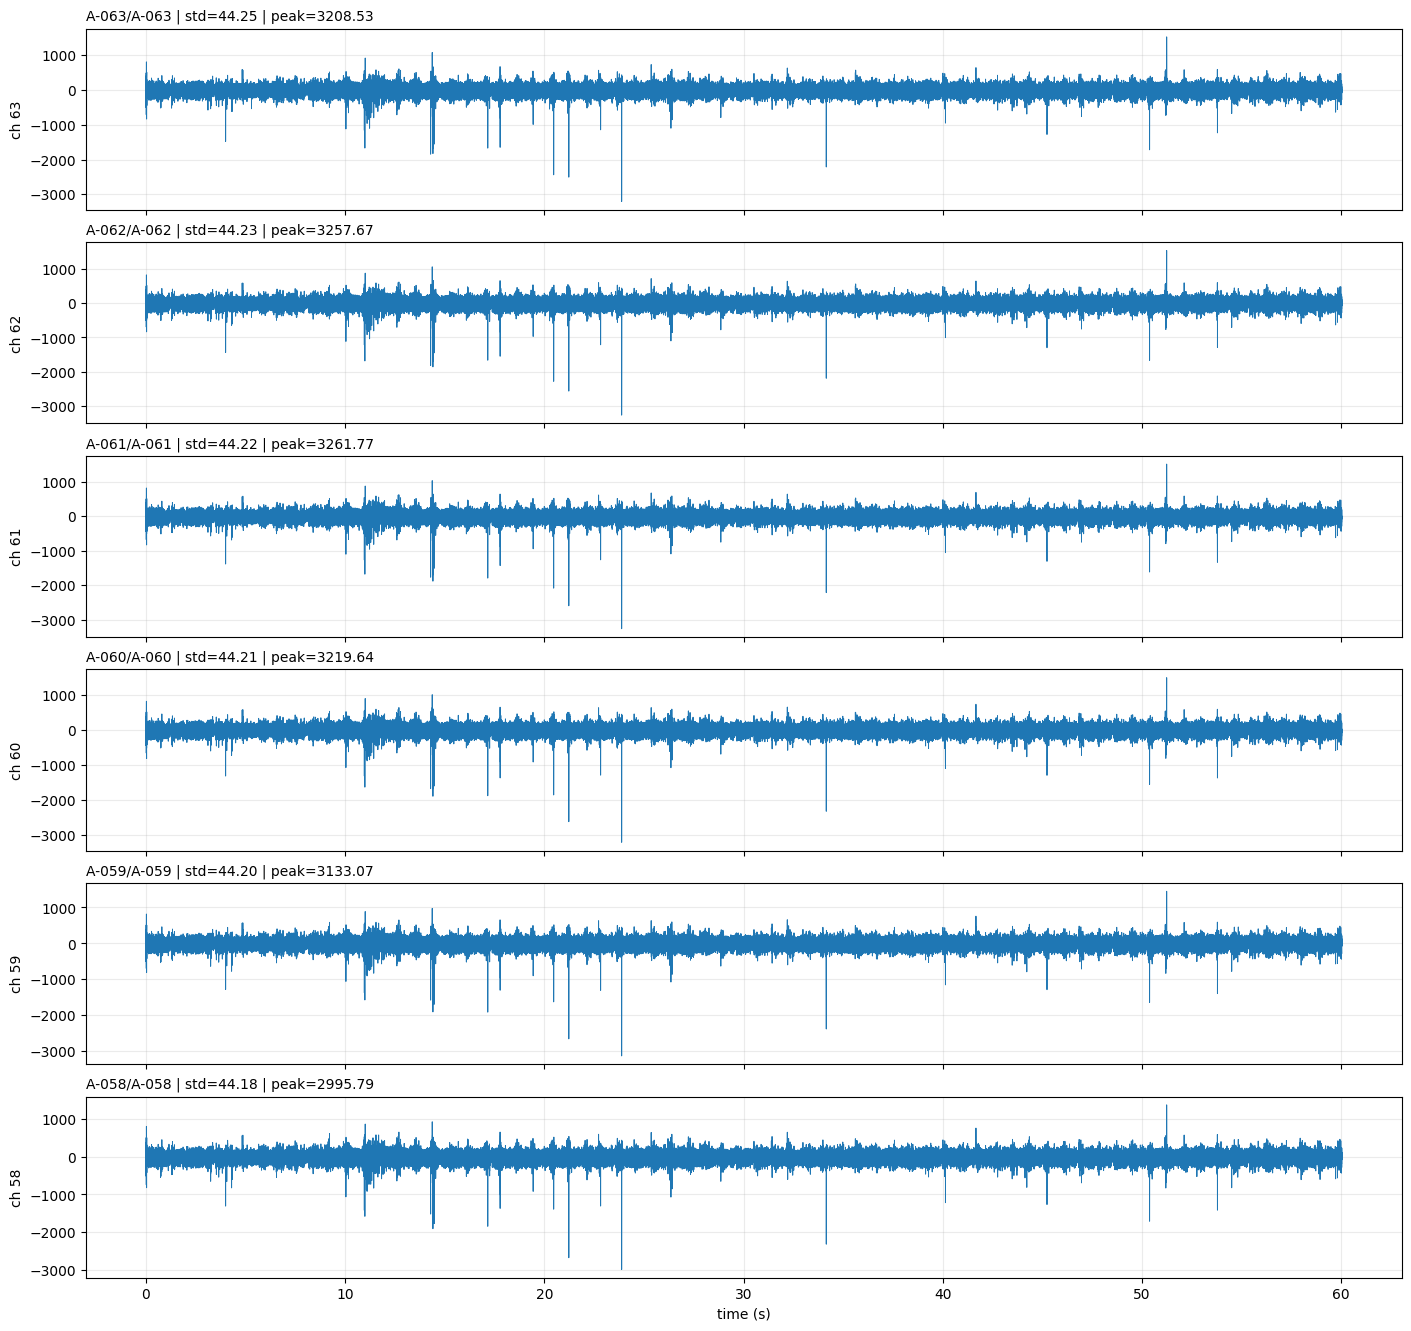

In [5]:
# Change this to any .rhd file relative to data_root
specific_rel_path = "RAT7_DORSIFLEXION/dorsi_170508_114443.rhd"
specific_file = data_root / specific_rel_path

if not specific_file.exists():
    raise FileNotFoundError(f"Specific file not found: {specific_file}")

specific_data = read_rhd(str(specific_file))
amp = specific_data.get("amplifier_data")
amp_channels = specific_data.get("amplifier_channels", [])
freq = specific_data.get("frequency_parameters", {})
fs = float(freq.get("amplifier_sample_rate", np.nan))

if amp is None:
    raise RuntimeError("No amplifier_data in this file")

n_ch = amp.shape[0] if amp.ndim == 2 else 1
n_samples = amp.shape[1] if amp.ndim == 2 else amp.shape[0]
duration_sec = n_samples / fs if np.isfinite(fs) and fs > 0 else np.nan

print("=" * 100)
print(f"Specific file: {specific_file.relative_to(data_root)}")
print(f"Sampling rate: {fs:.3f} Hz")
print(f"Samples: {n_samples}")
print(f"Channels: {n_ch}")
print(f"Duration: {duration_sec:.3f} s")
print("=" * 100)

print("\nAMPLIFIER CHANNEL METADATA (full dump):")
for i, ch in enumerate(amp_channels):
    print(f"\n--- Channel {i} ---")
    if isinstance(ch, dict):
        for k in sorted(ch.keys()):
            print(f"{k}: {ch[k]}")
    else:
        print(ch)

rows = []
for ch_idx in range(n_ch):
    sig = np.asarray(amp[ch_idx] if amp.ndim == 2 else amp, dtype=float)
    ch_meta = amp_channels[ch_idx] if ch_idx < len(amp_channels) else {}
    rows.append({
        "channel_index": ch_idx,
        "native_name": ch_meta.get("native_channel_name", f"ch_{ch_idx}"),
        "custom_name": ch_meta.get("custom_channel_name", ""),
        "std_uV": float(np.std(sig)),
        "rms_uV": float(np.sqrt(np.mean(sig**2))),
        "peak_abs_uV": float(np.max(np.abs(sig))),
    })

ranked = sorted(rows, key=lambda r: r["std_uV"], reverse=True)
print("\nTop channels by std_uV in specific file:")
for i, r in enumerate(ranked[:15], start=1):
    print(
        f"{i:02d}. ch={r['channel_index']} ({r['native_name']}/{r['custom_name']}) "
        f"std={r['std_uV']:.3f}, rms={r['rms_uV']:.3f}, peak_abs={r['peak_abs_uV']:.3f}"
    )

top_k = min(6, len(ranked))
fig, axes = plt.subplots(top_k, 1, figsize=(14, 2.2 * top_k), sharex=True, constrained_layout=True)
if top_k == 1:
    axes = [axes]

time_axis = np.arange(n_samples) / fs if np.isfinite(fs) and fs > 0 else np.arange(n_samples)
for ax, row in zip(axes, ranked[:top_k]):
    sig = np.asarray(amp[row["channel_index"]] if amp.ndim == 2 else amp, dtype=float)
    ax.plot(time_axis, sig, linewidth=0.7)
    ax.set_ylabel(f"ch {row['channel_index']}")
    ax.set_title(
        f"{row['native_name']}/{row['custom_name']} | std={row['std_uV']:.2f} | peak={row['peak_abs_uV']:.2f}",
        loc="left",
        fontsize=10,
    )
    ax.grid(True, alpha=0.25)
axes[-1].set_xlabel("time (s)")
plt.show()

## 3) Concatenate `DORSI_PLANTAR_PART1 + PART2` and compare with `.mat` target

Steps:

1. Group folders by base trial name (remove `_PART1`, `_PART2`, etc.).
2. Concatenate all matching `.rhd` files in filename order.
3. Load `.mat` time-angle target.
4. Interpolate concatenated `.rhd` signal to `.mat` timeline.
5. Plot both and shade movement regimes:

- Green: dorsiflexion (`angle >= 0`)
- Red: plantarflexion (`angle < 0`)

If your sign convention is opposite, invert those masks in the next cell.

Found 7 DORSI_PLANTAR trial groups
  - RAT10_DORSI_PLANTAR
  - RAT4_DORSI_PLANTAR
  - RAT5_DORSI_PLANTAR
  - RAT6_DORSI_PLANTAR
  - RAT7_DORSI_PLANTAR
  - RAT8_DORSI_PLANTAR
  - RAT9_DORSI_PLANTAR

Selected trial: RAT10_DORSI_PLANTAR
RHD files:
  - RAT10_DORSI_PLANTAR_PART1\dorsiplantar_170605_123454.rhd
  - RAT10_DORSI_PLANTAR_PART1\dorsiplantar_170605_123554.rhd
  - RAT10_DORSI_PLANTAR_PART1\dorsiplantar_170605_123655.rhd
  - RAT10_DORSI_PLANTAR_PART1\dorsiplantar_170605_123755.rhd
  - RAT10_DORSI_PLANTAR_PART2\dorsiplantar_170605_123855.rhd
  - RAT10_DORSI_PLANTAR_PART2\dorsiplantar_170605_123955.rhd
MAT file: RAT10_DORSI_PLANTAR_PART2\time_angle_allframes.mat


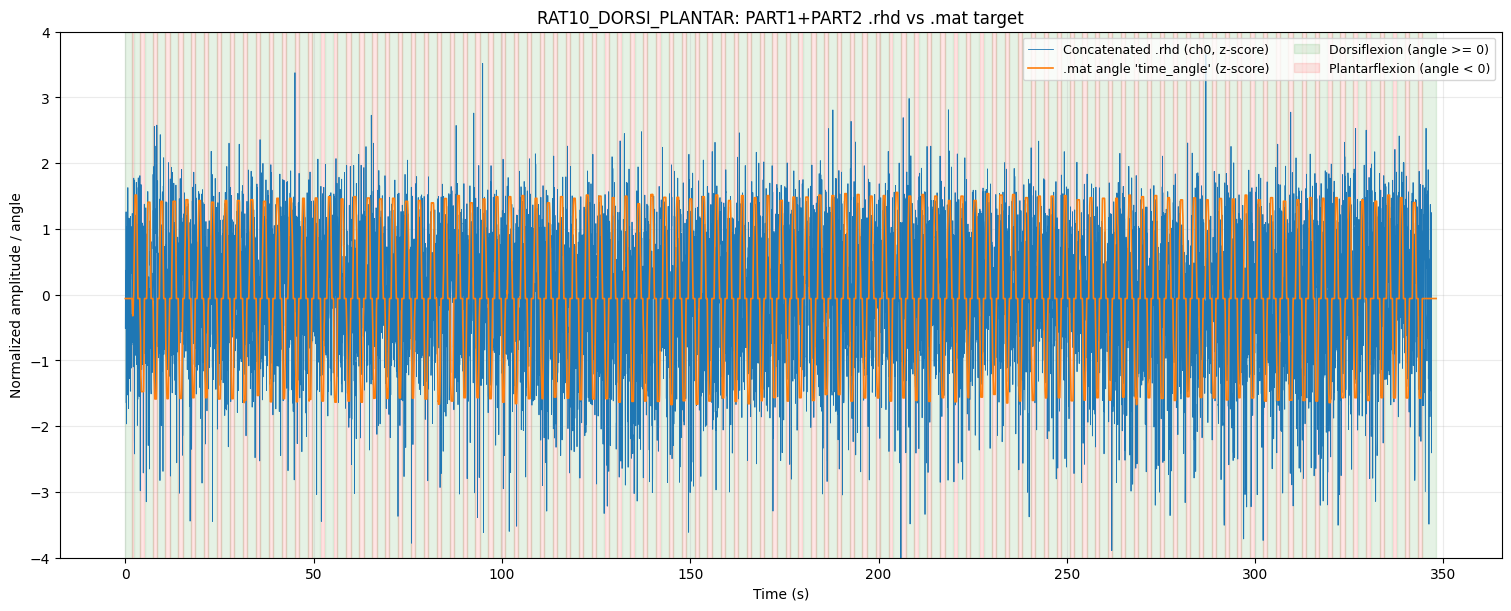


Interpretation guide:
- Green regions: dorsiflexion under this sign convention.
- Red regions: plantarflexion under this sign convention.
- If signs are reversed in your setup, swap the mask definitions.


In [6]:
rhd_by_folder = defaultdict(list)
for fp in rhd_files:
    rhd_by_folder[fp.parent].append(fp)

mat_by_folder = defaultdict(list)
for fp in mat_files:
    mat_by_folder[fp.parent].append(fp)

groups = defaultdict(lambda: {"rhd": [], "mat": []})
all_folders = set(rhd_by_folder.keys()).union(set(mat_by_folder.keys()))
for folder in all_folders:
    base = re.sub(r"_PART\d+$", "", folder.name)
    groups[base]["rhd"].extend(rhd_by_folder.get(folder, []))
    groups[base]["mat"].extend(mat_by_folder.get(folder, []))

def extract_mat_time_angle(mat_path):
    mat_data = loadmat(str(mat_path))
    keys = [k for k in mat_data.keys() if not k.startswith("__")]
    for key in keys:
        arr = np.asarray(mat_data[key])
        if arr.ndim >= 2 and arr.shape[1] >= 2 and np.issubdtype(arr.dtype, np.number):
            return key, np.asarray(arr[:, 0], dtype=float), np.asarray(arr[:, 1], dtype=float)
    raise ValueError(f"No numeric Nx2 time-angle variable found in {mat_path.name}")

target_trials = sorted([name for name in groups.keys() if "DORSI_PLANTAR" in name])
print(f"Found {len(target_trials)} DORSI_PLANTAR trial groups")
for name in target_trials[:10]:
    print(f"  - {name}")

if not target_trials:
    raise RuntimeError("No DORSI_PLANTAR groups found")

trial_name = target_trials[0]
trial = groups[trial_name]
if not trial["rhd"] or not trial["mat"]:
    raise RuntimeError(f"Trial {trial_name} missing .rhd or .mat files")

rhd_trial_files = sorted(trial["rhd"], key=lambda p: p.name)
mat_file = sorted(trial["mat"])[0]

print(f"\nSelected trial: {trial_name}")
print("RHD files:")
for f in rhd_trial_files:
    print(f"  - {f.relative_to(data_root)}")
print(f"MAT file: {mat_file.relative_to(data_root)}")

concat_signal = []
concat_time = []
offset = 0.0

for rf in rhd_trial_files:
    d = read_rhd(str(rf))
    amp = d.get("amplifier_data")
    fs = float(d.get("frequency_parameters", {}).get("amplifier_sample_rate", np.nan))
    if amp is None or not np.isfinite(fs) or fs <= 0:
        print(f"Skipping {rf.name}: missing amplifier_data or invalid fs")
        continue

    sig = np.asarray(amp[0] if amp.ndim == 2 else amp, dtype=float)
    t_local = np.arange(sig.shape[0]) / fs
    concat_signal.append(sig)
    concat_time.append(t_local + offset)
    offset += t_local[-1] + (1.0 / fs)

if not concat_signal:
    raise RuntimeError("Failed to build concatenated .rhd signal")

full_signal = np.concatenate(concat_signal)
full_time = np.concatenate(concat_time)

mat_key, mat_time, mat_angle = extract_mat_time_angle(mat_file)
signal_on_mat = np.interp(mat_time, full_time, full_signal, left=np.nan, right=np.nan)

sig_norm = (signal_on_mat - np.nanmean(signal_on_mat)) / (np.nanstd(signal_on_mat) + 1e-12)
ang_norm = (mat_angle - np.nanmean(mat_angle)) / (np.nanstd(mat_angle) + 1e-12)

fig, ax = plt.subplots(figsize=(15, 6), constrained_layout=True)
ax.plot(mat_time, sig_norm, color="tab:blue", linewidth=0.6, label="Concatenated .rhd (ch0, z-score)")
ax.plot(mat_time, ang_norm, color="tab:orange", linewidth=1.2, label=f".mat angle '{mat_key}' (z-score)")

dorsi_mask = mat_angle >= 0
plantar_mask = mat_angle < 0
ax.fill_between(mat_time, -4, 4, where=dorsi_mask, color="green", alpha=0.10, label="Dorsiflexion (angle >= 0)")
ax.fill_between(mat_time, -4, 4, where=plantar_mask, color="red", alpha=0.10, label="Plantarflexion (angle < 0)")

ax.set_title(f"{trial_name}: PART1+PART2 .rhd vs .mat target")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Normalized amplitude / angle")
ax.set_ylim(-4, 4)
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", ncol=2, fontsize=9)
plt.show()

print("\nInterpretation guide:")
print("- Green regions: dorsiflexion under this sign convention.")
print("- Red regions: plantarflexion under this sign convention.")
print("- If signs are reversed in your setup, swap the mask definitions.")